# **Redes Neuronales para el Análisis de Series Temporales**
<b> Diplomatura de Especialización en Desarrollo de Aplicaciones con Inteligencia Artificial</b>

**PROYECTO FINAL :** Visualización y Análisis de Electrocardiograma

**Docente:** Mg. Pablo Fonseca (pfonseca@pucp.edu.pe)

**Integrantes:**
- Jhancarlo Florencio Silva Ochoa
- Brian Vargas Oros
- Renzo Villalobos Cafferata
- Julio Cesar Tejada Manrique
- Felipe Jimenez Gutierrez

#📌 **1. Introducción**

El trabajo final consiste en crear un sistema de visualización de series temporales de ECG usando Streamlit y publicarlo finalmente en Streamlit Community Cloud. El proyecto tendrá un componente de (i) visualización apropiada al dominio y (ii) análisis de las señales. Puede referirse a
la siguiente discusión sobre la relevancia de los dashboards para publicar resultados de investigación.

#📌 **2. Dataset**
A large scale 12-lead electrocardiogram database for arrhythmia study
https://physionet.org/content/ecg-arrhythmia/1.0.0/
Este dataset de investigación contiene señales de ECG de 12 derivaciones, desarrollado en colaboración con Chapman University, Shaoxing People’s Hospital (Shaoxing Hospital Zhejiang University School of Medicine) y Ningbo First Hospital, y se utiliza para apoyar estudios sobre arritmias —como la fibrilación auricular, que impacta la salud pública, la calidad de vida y los costos médicos— y otras afecciones cardiovasculares; siendo un examen no invasivo, el ECG genera grandes volúmenes de datos que requieren análisis experto, y las técnicas modernas de machine learning y herramientas estadísticas, entrenadas con datos de alta calidad, pueden alcanzar altos niveles de precisión diagnóstica automatizada, lo que se complementa con un conjunto que incluye ECGs de 45,152 pacientes con una tasa de muestreo de 500 Hz, abarcando múltiples ritmos comunes y condiciones adicionales, todos etiquetados por profesionales, ideal para diseñar, comparar y optimizar métodos en investigaciones cardiovasculares.




#📌 **3. Objetivos**

##📌 **3.1. O1 - Descargar la data y visualizar los ECG en Streamlit siguiendo las reglas del papel electrocardiográfico.**

El papel electrocardiográfico es una cuadrícula milimetrada tanto en sentido horizontal como en sentido vertical. Cada 5 mm las líneas de la cuadrícula se hacen más gruesas, quedando así marcados cuadrados grandes de 5 mm x 5 mm y cuadrados chicos de 1 mm x 1 mm. Horizontalmente, el papel de registro corre a una velocidad constante de 25 mm/seg, por lo que cada milímetro equivale a 0.04 segundos o 40 milisegundos, y un cuadrado grande a 0.20 segundos o 20 milisegundos. Verticalmente se mide el voltaje o amplitud de los elementos del electrocardiograma. La calibración convencional establece que 1 cm de amplitud equivale a 1 mV, por lo que 1 mm es igual a 0.1 mV y un cuadrado grande de 5 mm a 0.5 mVel papel de EKG equivale a 0.1 mV y cada cuadro grande 0.5 mV.


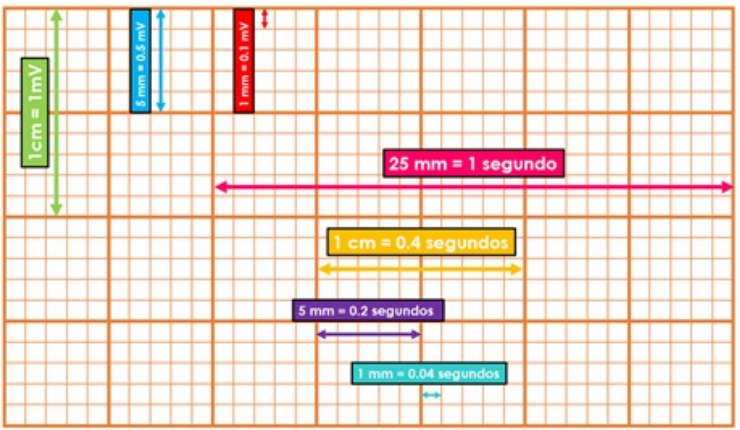

##📌 **3.2. O2 - O2 - Análisis de frecuencia cardiaca.**

Usando neurokit2 identificar los picos R y calcular la frecuencia
cardiaca. Esta información se debe visualizar junto a las señales mostradas. Debe lanzar una alerta para frecuencias cardiacas fuera del rango (60-100). Para eso debe escoger una derivada apropiada. Recuerde que existen varios métodos para calcular la frecuencia cardíaca. Todos ellos se basan en que la frecuencia cardíaca es el inverso del intervalo RR y en la calibración del electrocardiograma, en donde 25 mm equivalen a 1 segundo. El inverso de un número X es 1/X, por lo que el inverso de una frecuencia cardíaca de 80 latidos por minuto (80 latidos/60 segundos) es 60/80 = 0.75 segundos (el valor del intervalo RR para una frecuencia cardíaca de 80 lpm). El mismo proceso se puede llevar a cabo despejando la frecuencia cardíaca cuando el valor conocido es el intervalo RR, con lo que 60/0.75 = 80 lpm. Por lo tanto, un minuto (60 segundos) dividido entre el intervalo RR (en segundos) resulta en el valor de la frecuencia cardíaca (en latidos por minuto).



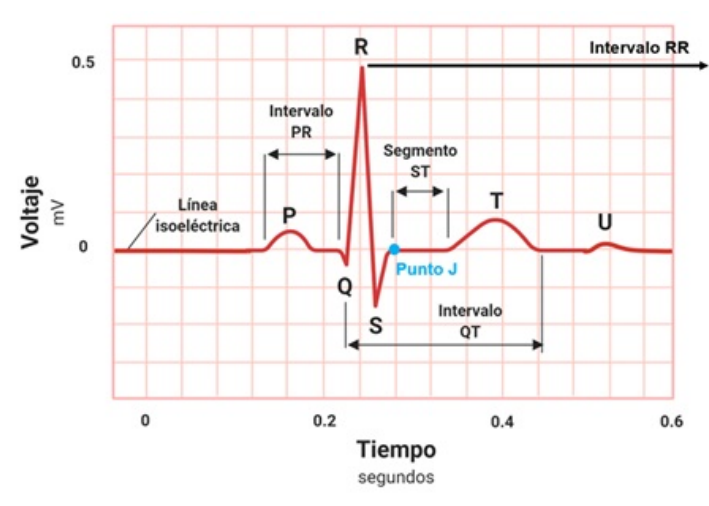

#📌 **4. Desarrollo del trabajo**

##📌 **4.1. Instalacion de librerias**

wfdb → leer señales ECG desde PhysioNet

plotly → gráficos interactivos

ipywidgets → interfaz en Jupyter/Colab

streamlit → app web

pyngrok → exponer la app en internet

neurokit2 → procesamiento de ECG (detección de picos R)

In [1]:
!pip install wfdb plotly ipywidgets pandas numpy
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which i

In [2]:
!pip install pyngrok
!pip install neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


##📌 **4.2. Configuracion de ngrok**

Autentica tu cuenta de ngrok y permite generar una URL pública para tu app

In [3]:
from pyngrok import ngrok
ngrok.kill()
ngrok.set_auth_token("3C12HM7aAGaIbXBFmYwSawAzTMm_7RhowyEw4PCSdZLKUfkJC")

##📌 **4.3. Configuracion Inicial**

Realizamos imports generales para manejo de datos, visualizacion e interfaz interactiva.

BASE_URL → dataset ECG (PhysioNet)

LEADS_12 → derivaciones estándar ECG

CACHE_DIR → carpeta temporal para guardar archivos descargados



In [4]:
import json
import tempfile
import urllib.request
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import wfdb
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Constantes ─────────────────────────────────────────────────────────────────
BASE_URL   = "https://physionet.org/files/ecg-arrhythmia/1.0.0"
LEADS_12   = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
CACHE_DIR  = Path(tempfile.gettempdir()) / "ecg_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Imports OK")
print(f"📁 Caché de registros en: {CACHE_DIR}")

✅ Imports OK
📁 Caché de registros en: /tmp/ecg_cache


##📌 **4.4. Parseo del dataset (estructura de archivos)**

Se lee el archivo SHA256SUMS.txt para construir una estructura que nos sirva mas adelante para una navegacion por tipo:

Carpeta → Subcarpeta → Registro ECG

In [5]:
# ── Celda 2 — Descarga SHA256SUMS.txt y parsea el árbol ───────────────────────

SHA256_URL  = "https://physionet.org/files/ecg-arrhythmia/1.0.0/SHA256SUMS.txt"
SHA256_FILE = Path("SHA256SUMS.txt")

# Descargar solo si no existe localmente
if not SHA256_FILE.exists():
    print("⬇️  Descargando SHA256SUMS.txt desde PhysioNet...")
    urllib.request.urlretrieve(SHA256_URL, SHA256_FILE)
    print(f"✅ Descargado ({SHA256_FILE.stat().st_size / 1024:.0f} KB)")
else:
    print(f"✅ SHA256SUMS.txt encontrado localmente")

def parse_tree(sums_file: str = "SHA256SUMS.txt") -> dict:
    tree = defaultdict(lambda: defaultdict(list))

    with open(sums_file) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 2:
                continue
            path = parts[1]
            if not path.startswith("WFDBRecords/") or not path.endswith(".hea"):
                continue
            segments = path.split("/")
            if len(segments) != 4:
                continue
            _, folder, subfolder, filename = segments
            record = filename.replace(".hea", "")
            tree[folder][subfolder].append(record)

    return {
        f: {sf: sorted(recs) for sf, recs in sorted(subs.items())}
        for f, subs in sorted(tree.items())
    }

TREE = parse_tree()

total_records = sum(len(r) for subs in TREE.values() for r in subs.values())
print(f"\n📊 Árbol parseado:")
print(f"   Carpetas   : {len(TREE)}")
print(f"   Subcarpetas: {sum(len(s) for s in TREE.values())}")
print(f"   Registros  : {total_records:,}")
print(f"\nEjemplo → TREE['01']['010'][:5] = {TREE['01']['010'][:5]}")

⬇️  Descargando SHA256SUMS.txt desde PhysioNet...
✅ Descargado (8507 KB)

📊 Árbol parseado:
   Carpetas   : 46
   Subcarpetas: 452
   Registros  : 45,152

Ejemplo → TREE['01']['010'][:5] = ['JS00001', 'JS00002', 'JS00004', 'JS00005', 'JS00006']


##📌 **4.5. Descarga de registros ECG**

**def fetch_record**

  **Función:**
  Descarga archivos:
  1.   .hea → metadata
  2.   .mat → señal ECG
  3.   Usa caché local

  **Flujo:**
  1.   Verifica si el archivo existe
  2.   Si no → descarga
  3.   Carga con wfdb.rdrecord

  **Testeo donde se mostrará:**
  1.   Frecuencia de muestreo
  2.   Duración
  3.   Número de derivaciones
  4.   Forma de la señal


    
    
    

  

  


In [6]:
# ── Celda 3 — Descarga bajo demanda de un registro ────────────────────────────

def fetch_record(folder: str, subfolder: str, record: str) -> wfdb.Record:
    """
    Descarga .hea y .mat desde PhysioNet solo si no están en caché.
    Retorna un objeto wfdb.Record listo para usar.
    """
    record_dir = CACHE_DIR / folder / subfolder
    record_dir.mkdir(parents=True, exist_ok=True)

    rel_path = f"WFDBRecords/{folder}/{subfolder}/{record}"

    for ext in [".hea", ".mat"]:
        local_file = record_dir / f"{record}{ext}"
        if not local_file.exists():
            url = f"{BASE_URL}/{rel_path}{ext}"
            print(f"⬇️  Descargando {record}{ext}...")
            urllib.request.urlretrieve(url, local_file)
        else:
            print(f"📦 {record}{ext} ya en caché")

    rec = wfdb.rdrecord(str(record_dir / record))
    return rec

# ── Test: carga el primer registro disponible ──────────────────────────────────
_f  = list(TREE.keys())[0]
_sf = list(TREE[_f].keys())[0]
_r  = TREE[_f][_sf][0]

print(f"🧪 Probando con: WFDBRecords/{_f}/{_sf}/{_r}\n")
rec_test = fetch_record(_f, _sf, _r)

print(f"\n✅ Registro cargado:")
print(f"   ID          : {_r}")
print(f"   Frecuencia  : {rec_test.fs} Hz")
print(f"   Duración    : {rec_test.sig_len / rec_test.fs:.1f} s")
print(f"   Derivaciones: {rec_test.sig_name}")
print(f"   Shape señal : {rec_test.p_signal.shape}")

🧪 Probando con: WFDBRecords/01/010/JS00001

⬇️  Descargando JS00001.hea...
⬇️  Descargando JS00001.mat...

✅ Registro cargado:
   ID          : JS00001
   Frecuencia  : 500 Hz
   Duración    : 10.0 s
   Derivaciones: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
   Shape señal : (5000, 12)


##📌 **4.6. Interfaz con Widgets + Streamlit con ngrok**

Esta porción de código implementa una interfaz interactiva en Google Colab que permite seleccionar registros ECG y lanzar una aplicación web en Streamlit, accesible mediante una URL pública generada con ngrok.

**Se logra con esto:**


*   Facilitar la selección dinámica de datos ECG (carpeta, subcarpeta y registro)
*   Construir automáticamente una aplicación web interactiva
*   Permitir la visualización y análisis del ECG en tiempo real
*   Exponer la aplicación local a internet mediante ngrok


Lo que haremos con esta parte es crea selectores interactivos con **ipywidgets:**

*   Carpeta
*   Subcarpeta
*   Registro

Con el fin de que la logica sea mas interactiva:

*   Cambiar carpeta → actualiza subcarpetas
*   Cambiar subcarpeta → actualiza registros

**Generación dinámica de la app (APP_CODE)**

Se define un string que contiene todo el código de la **aplicación Streamlit:**

Incluye:

*   Carga de datos desde PhysioNet
*   Caché de datos
*   Procesamiento de señal ECG
*   Detección de picos R
*   Cálculo de frecuencia cardíaca
*   Visualización interactiva con Plotly
*   Métricas clínicas
*   Estadísticas de señal


**Al presional el boton "Lanza App"**

*   Se guarda el código como app.py
*   Se ejecuta Streamlit en segundo plano
*   Se abre un túnel con ngrok
*   Se genera una URL pública

**Integración con ngrok**

*   Convierte el servidor local (localhost:8501) en una URL pública
*   Permite compartir la aplicación sin necesidad de despliegue en la nube










In [7]:
# ── Celda 4 — Widgets + Streamlit con ngrok (Colab) ───────────────────────────
import subprocess, sys, threading, time
from pyngrok import ngrok

# ── Widgets ────────────────────────────────────────────────────────────────────
w_folder    = widgets.Dropdown(description="Carpeta:", options=sorted(TREE.keys()))
w_subfolder = widgets.Dropdown(description="Subcarpeta:")
w_record    = widgets.Dropdown(description="Registro:")
w_button    = widgets.Button(description="⚡ Lanzar app", button_style="success",
                              layout=widgets.Layout(width="160px"))
w_status    = widgets.Output()

def on_folder_change(change):
    subfolders = sorted(TREE[change["new"]].keys())
    w_subfolder.options = subfolders
    w_subfolder.value   = subfolders[0]

def on_subfolder_change(change):
    folder = w_folder.value
    if change["new"] in TREE[folder]:
        records = TREE[folder][change["new"]]
        w_record.options = records
        w_record.value   = records[0]

w_folder.observe(on_folder_change, names="value")
w_subfolder.observe(on_subfolder_change, names="value")
on_folder_change({"new": w_folder.value})

# ── App Streamlit (se escribe dinámicamente) ───────────────────────────────────
APP_CODE = '''
import json, tempfile, urllib.request
from collections import defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import streamlit as st
import wfdb
import neurokit2 as nk

BASE_URL  = "https://physionet.org/files/ecg-arrhythmia/1.0.0"
LEADS_12  = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
CACHE_DIR = Path(tempfile.gettempdir()) / "ecg_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

@st.cache_data(show_spinner=False)
def load_tree():
    path = Path("SHA256SUMS.txt")
    if not path.exists():
        urllib.request.urlretrieve(f"{BASE_URL}/SHA256SUMS.txt", path)
    tree = defaultdict(lambda: defaultdict(list))
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 2: continue
            p = parts[1]
            if not p.startswith("WFDBRecords/") or not p.endswith(".hea"): continue
            segs = p.split("/")
            if len(segs) != 4: continue
            _, folder, subfolder, fname = segs
            tree[folder][subfolder].append(fname.replace(".hea",""))
    return {f: {sf: sorted(r) for sf, r in sorted(s.items())}
            for f, s in sorted(tree.items())}

@st.cache_data(show_spinner=False)
def fetch_record(folder, subfolder, record):
    record_dir = CACHE_DIR / folder / subfolder
    record_dir.mkdir(parents=True, exist_ok=True)
    rel = f"WFDBRecords/{folder}/{subfolder}/{record}"
    for ext in [".hea", ".mat"]:
        local = record_dir / f"{record}{ext}"
        if not local.exists():
            urllib.request.urlretrieve(f"{BASE_URL}/{rel}{ext}", local)
    return wfdb.rdrecord(str(record_dir / record))

@st.cache_data(show_spinner=False)
def detect_r_peaks(signal_full, fs):
    signal_clean = nk.ecg_clean(signal_full, sampling_rate=fs)
    _, info = nk.ecg_peaks(signal_clean, sampling_rate=fs)
    return info["ECG_R_Peaks"]

# ── Layout ─────────────────────────────────────────────────────────────────────
st.set_page_config(page_title="ECG Viewer", page_icon="🫀", layout="wide")
st.title("🫀 Visualizador de Electrocardiograma")

TREE = load_tree()

with st.sidebar:
    st.markdown("### 📂 Selección de registro")
    folder    = st.selectbox("Carpeta", sorted(TREE.keys()))
    subfolder = st.selectbox("Subcarpeta", sorted(TREE[folder].keys()))
    record    = st.selectbox("Registro", TREE[folder][subfolder])
    load_btn  = st.button("⚡ Cargar registro", use_container_width=True)

if load_btn:
    with st.spinner("Descargando..."):
        rec = fetch_record(folder, subfolder, record)
    st.session_state.rec = rec

rec = st.session_state.get("rec", None)

if rec is None:
    st.info("👈 Selecciona un registro y pulsa Cargar.")
    st.stop()

# ── Métricas básicas ───────────────────────────────────────────────────────────
c1, c2, c3, c4 = st.columns(4)
c1.metric("Registro", record)
c2.metric("Frecuencia", f"{rec.fs} Hz")
c3.metric("Duración", f"{rec.sig_len/rec.fs:.1f} s")
c4.metric("Derivaciones", rec.n_sig)

# ── Controles visualización ────────────────────────────────────────────────────
with st.sidebar:
    st.markdown("### 🔬 Visualización")
    leads_sel  = st.multiselect("Derivaciones", LEADS_12, default=LEADS_12)
    zoom_start = st.number_input("Inicio (s)", 0.0, float(rec.sig_len/rec.fs), 0.0, 0.5)
    zoom_end   = st.number_input("Fin (s)", 0.0, float(rec.sig_len/rec.fs),
                                  min(10.0, rec.sig_len/rec.fs), 0.5)

if not leads_sel or zoom_end <= zoom_start:
    st.warning("Ajusta el rango o selecciona al menos una derivación.")
    st.stop()

# ── Variables comunes ──────────────────────────────────────────────────────────
fs    = rec.fs
i0    = int(zoom_start * fs)
i1    = int(zoom_end * fs)
t     = np.arange(i0, i1) / fs
sig   = rec.p_signal
avail = rec.sig_name

leads_plot = [l for l in leads_sel if l in avail]
n = len(leads_plot)

colors = ["#00f5d4","#f72585","#4cc9f0","#fee440",
          "#fb5607","#8338ec","#06d6a0","#ff006e",
          "#3a86ff","#ffbe0b","#43aa8b","#f94144"]

# ── Parámetros papel ECG ───────────────────────────────────────────────────────
SMALL_T  = 0.04
LARGE_T  = 0.20
SMALL_MV = 0.10
LARGE_MV = 0.50
OFFSET   = 1.8

y_min = -LARGE_MV
y_max = (n - 1) * OFFSET + LARGE_MV

# ── Detección picos R y HR ─────────────────────────────────────────────────────
LEAD_PRIORITY = ["II", "I", "III", "aVF", "V5", "V6"]
lead_hr = next((l for l in LEAD_PRIORITY if l in avail), avail[0])
idx_hr  = avail.index(lead_hr)

r_peaks = detect_r_peaks(sig[:, idx_hr], fs)

if len(r_peaks) >= 2:
    rr_intervals = np.diff(r_peaks) / fs
    mean_rr      = np.mean(rr_intervals)
    heart_rate   = round(60 / mean_rr, 1)
else:
    heart_rate = None
    mean_rr    = None

# ── Métricas HR ────────────────────────────────────────────────────────────────
st.markdown("---")
st.markdown("#### 💓 Frecuencia Cardíaca")
col_hr1, col_hr2, col_hr3, col_hr4 = st.columns(4)
col_hr1.metric("Derivada usada", lead_hr)

if heart_rate is not None:
    col_hr2.metric("Frecuencia cardíaca", f"{heart_rate} lpm")
    col_hr3.metric("Intervalo RR medio", f"{mean_rr*1000:.1f} ms")
    col_hr4.metric("Picos R detectados", len(r_peaks))

    if heart_rate < 60:
        st.warning(f"⚠️ **Bradicardia** — FC {heart_rate} lpm está por debajo de 60 lpm")
    elif heart_rate > 100:
        st.error(f"🚨 **Taquicardia** — FC {heart_rate} lpm está por encima de 100 lpm")
    else:
        st.success(f"✅ **FC normal** — {heart_rate} lpm (rango 60–100 lpm)")
else:
    st.error("❌ No se detectaron suficientes picos R para calcular la FC")

st.markdown("---")

# ── Grilla papel ECG ───────────────────────────────────────────────────────────
shapes = []
t_start = round(zoom_start / SMALL_T) * SMALL_T
t_ticks = np.arange(t_start, zoom_end, SMALL_T)

for tv in t_ticks:
    is_large = abs(round(tv / LARGE_T) * LARGE_T - tv) < 1e-6
    shapes.append(dict(
        type="line", x0=tv, x1=tv, y0=y_min, y1=y_max,
        line=dict(color="#e8a0a0" if is_large else "#f5c5c5",
                  width=0.8 if is_large else 0.3),
        layer="below",
    ))

for i in range(n):
    center   = (n - 1 - i) * OFFSET
    mv_ticks = np.arange(center - OFFSET/2, center + OFFSET/2 + SMALL_MV, SMALL_MV)
    for mv in mv_ticks:
        is_large = abs(round((mv - center) / LARGE_MV) * LARGE_MV - (mv - center)) < 1e-6
        shapes.append(dict(
            type="line", x0=zoom_start, x1=zoom_end, y0=mv, y1=mv,
            line=dict(color="#e8a0a0" if is_large else "#f5c5c5",
                      width=0.8 if is_large else 0.3),
            layer="below",
        ))

# ── Trazados ECG ───────────────────────────────────────────────────────────────
fig = go.Figure()

for i, lead in enumerate(leads_plot):
    idx   = avail.index(lead)
    y_raw = sig[i0:i1, idx]
    y_off = y_raw - np.nanmean(y_raw) + (n - 1 - i) * OFFSET
    fig.add_trace(go.Scatter(
        x=t, y=y_off, mode="lines", name=lead,
        line=dict(width=1.2, color=colors[i % len(colors)]),
        hovertemplate=f"<b>{lead}</b><br>t=%{{x:.3f}} s<br>%{{customdata:.3f}} mV<extra></extra>",
        customdata=y_raw,
    ))
    fig.add_annotation(
        x=zoom_start, y=(n - 1 - i) * OFFSET,
        text=f"<b>{lead}</b>", showarrow=False,
        xanchor="right", xshift=-6,
        font=dict(color=colors[i % len(colors)], size=11),
    )

# ── Picos R sobre la figura ────────────────────────────────────────────────────
r_peaks_zoom = r_peaks[(r_peaks >= i0) & (r_peaks < i1)]

if lead_hr in leads_plot and len(r_peaks_zoom) > 0:
    i_lead   = leads_plot.index(lead_hr)
    y_raw_hr = sig[i0:i1, idx_hr]
    offset_hr = (n - 1 - i_lead) * OFFSET
    r_times  = r_peaks_zoom / fs
    r_values = sig[r_peaks_zoom, idx_hr] - np.nanmean(y_raw_hr) + offset_hr
    fig.add_trace(go.Scatter(
        x=r_times, y=r_values,
        mode="markers+text", name="Picos R",
        marker=dict(symbol="triangle-down", size=10,
                    color="#ffbe0b", line=dict(width=1, color="#ff8800")),
        text=["R"] * len(r_times),
        textposition="top center",
        textfont=dict(color="#ffbe0b", size=9),
        hovertemplate="<b>Pico R</b><br>t=%{x:.3f} s<extra></extra>",
    ))
elif lead_hr not in leads_plot:
    st.info(f"ℹ️ Derivada **{lead_hr}** (usada para HR) no está en el plot — agrégala para ver los picos R.")

# ── Calibración ────────────────────────────────────────────────────────────────
cal_x = zoom_start + LARGE_T * 0.3
cal_y = y_max - LARGE_MV * 1.5
fig.add_shape(type="line", x0=cal_x, x1=cal_x, y0=cal_y, y1=cal_y + 1.0,
              line=dict(color="#ffffff", width=2))
fig.add_annotation(x=cal_x, y=cal_y + 0.5, text="1 mV",
                   showarrow=False, xanchor="left", xshift=6,
                   font=dict(color="#ffffff", size=9))

fig.update_layout(
    paper_bgcolor="#1a0a0a", plot_bgcolor="#1a0a0a",
    font=dict(color="#c8ccd4"),
    shapes=shapes,
    xaxis=dict(
        title="Tiempo (s)",
        tickvals=np.arange(round(zoom_start/LARGE_T)*LARGE_T, zoom_end+LARGE_T, LARGE_T).tolist(),
        tickformat=".2f", showgrid=False, zeroline=False, color="#aaaaaa",
    ),
    yaxis=dict(showgrid=False, zeroline=False, tickvals=[], range=[y_min, y_max]),
    height=max(400, 80 * n),
    hovermode="x unified",
    margin=dict(l=80, r=20, t=30, b=50),
    legend=dict(bgcolor="rgba(26,10,10,0.7)", bordercolor="#3a1a1a", borderwidth=1),
)

st.plotly_chart(fig, use_container_width=True)

# ── Estadísticas ───────────────────────────────────────────────────────────────
with st.expander("📊 Estadísticas de señal"):
    rows = []
    for lead in leads_plot:
        idx = avail.index(lead)
        s   = sig[i0:i1, idx]
        rows.append({"Derivación": lead,
                     "Media (mV)": f"{np.nanmean(s):.4f}",
                     "Std (mV)":   f"{np.nanstd(s):.4f}",
                     "Min (mV)":   f"{np.nanmin(s):.4f}",
                     "Max (mV)":   f"{np.nanmax(s):.4f}"})
    st.dataframe(pd.DataFrame(rows), hide_index=True)
'''

# ── Botón: escribe app.py y lanza Streamlit + ngrok ───────────────────────────
proc_state = {"proc": None, "url": None}

def on_launch(b):
    with w_status:
        clear_output()
        with open("app.py", "w") as f:
            f.write(APP_CODE)
        if proc_state["proc"]:
            proc_state["proc"].terminate()
            ngrok.kill()
        proc_state["proc"] = subprocess.Popen(
            [sys.executable, "-m", "streamlit", "run", "app.py",
             "--server.port", "8501",
             "--server.headless", "true"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )
        time.sleep(4)
        ngrok.kill()
        tunnel = ngrok.connect(addr=8501, proto="http")
        proc_state["url"] = tunnel.public_url
        print(f"✅ App corriendo en: {tunnel.public_url}")

w_button.on_click(on_launch)

display(widgets.VBox([
    widgets.HTML("<b>📂 Selección de registro ECG</b>"),
    widgets.HBox([w_folder, w_subfolder, w_record, w_button]),
    w_status,
]))

##📌 **4.7. Resultado**

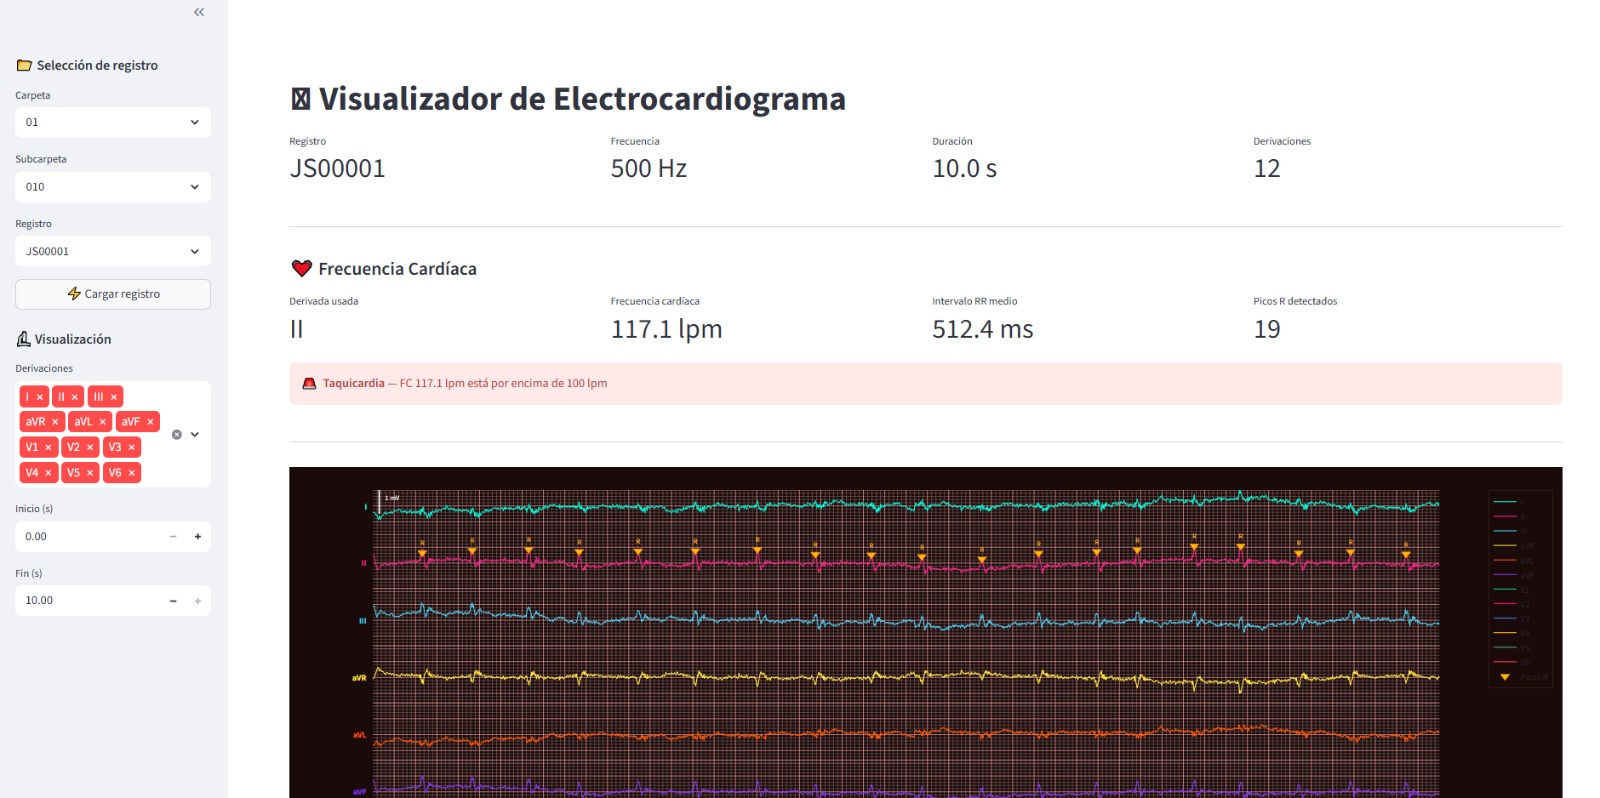
